# 금융규제 샌드박스 승인사례 기술축 탐색

## 1. 분석 목적

금융규제 샌드박스 승인사례를 사전에 AI·SaaS·Cloud 등으로 고정 분류하지 않고, 승인사례 **제목의 핵심 의미 구조**를 기반으로 주요 혁신 유형을 탐색한다.

분석 전에 반복적으로 등장하는 일반 표현을 먼저 제거하고, **동일한 정제 텍스트·동일한 Embedding 공간**에서 Elbow와 Silhouette Score를 함께 확인해 군집 수(K)를 결정한다.

**검증 질문**
- 전체 승인사례에서 어떤 기술·서비스 유형이 자연스럽게 형성되는가?
- AI·SaaS·Cloud와 관련된 군집이 실제로 구분되는가?
- 해당 유형의 승인 흐름은 연도별로 어떻게 변화하는가?

> 본 군집은 공식 정책 분류가 아니라 탐색적 유형화이다. 특정 기술군을 만들기 위해 K를 임의로 세분화하지 않는다.


## 2. 데이터 수집

금융규제 샌드박스 공개 목록에서 승인사례의 제목, 신청기업, 담당부처, 분야, 승인일을 수집한다.

기존 실행 결과 기준 **1,112건**이 수집되었다.

In [2]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

BASE_URL = "https://www.sandbox.go.kr"
LIST_URL = BASE_URL + "/sandbox.SandboxTaskSlPL"
DETAIL_URL = BASE_URL + "/sandbox.SandboxTaskSl"

Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

In [3]:
rows = []

for page in range(1, 113):

    payload = {
        "targetRow": str((page - 1) * 10 + 1),
        "pageNo": str(page),
        "mini_field_cd": "03",
        "exception_type": "",
        "rowCount": "10",
        "sch_text": ""
    }

    r = requests.post(LIST_URL, data=payload, timeout=30)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    for a in soup.select("a.c-text[onclick*='f_detilView']"):

        match = re.search(
            r"f_detilView\(['\"]?(\d+)",
            a.get("onclick", "")
        )

        if not match:
            continue

    
        # 핵심: a가 아니라 부모 카드 전체
       
        card = a.parent

        # 혹시 한 단계 위에 메타정보가 있으면 계속 확장
        while card and "승인일" not in card.get_text(" ", strip=True):
            card = card.parent

        card_text = (
            card.get_text(" ", strip=True)
            if card else ""
        )

        title_el = a.select_one(".c-tit")
        company_el = a.select_one(".sub-txt b")

        title = (
            title_el.get_text(" ", strip=True)
            if title_el else None
        )

        company = (
            company_el.get_text(" ", strip=True)
            if company_el else None
        )

        department_match = re.search(
            r"주관부처\s*:\s*(.*?)\s*(?=분야\s*:)",
            card_text
        )

        field_match = re.search(
            r"분야\s*:\s*(.*?)\s*(?=승인일\s*:)",
            card_text
        )

        date_match = re.search(
            r"승인일\s*:\s*(\d{4}-\d{2}-\d{2})",
            card_text
        )

        rows.append({
            "task_seq": match.group(1),
            "title": title,
            "company": company,
            "department": (
                department_match.group(1).strip()
                if department_match else None
            ),
            "field": (
                field_match.group(1).strip()
                if field_match else None
            ),
            "approval_date": (
                date_match.group(1)
                if date_match else None
            )
        })

    if page % 10 == 0 or page == 112:
        print(f"{page}/112 | {len(rows)}건")

    time.sleep(0.1)


df_list = pd.DataFrame(rows)

df_list["task_seq"] = df_list["task_seq"].astype(str)

df_list = (
    df_list
    .drop_duplicates("task_seq")
    .reset_index(drop=True)
)

df_list["approval_date"] = pd.to_datetime(
    df_list["approval_date"],
    errors="coerce"
)

print("전체:", len(df_list))
print("승인일:", df_list["approval_date"].notna().sum())
print("승인일 누락:", df_list["approval_date"].isna().sum())

display(df_list.head(10))

10/112 | 100건
20/112 | 200건
30/112 | 300건
40/112 | 400건
50/112 | 500건
60/112 | 600건
70/112 | 700건
80/112 | 800건
90/112 | 900건
100/112 | 1000건
110/112 | 1100건
112/112 | 1112건
전체: 1112
승인일: 1112
승인일 누락: 0


,task_seq,title,company,department,field,approval_date
0,2921,방한 외국인 대상 선불전자지급수단 발행 서비스,네이버파이낸셜,금융위원회(혁신금융),혁신금융,2026-07-15
1,2957,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,아이엠뱅크,금융위원회(혁신금융),혁신금융,2026-07-15
2,2955,공동대출 서비스,카카오뱅크(부산은행),금융위원회(혁신금융),혁신금융,2026-07-15
3,2956,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,경남은행,금융위원회(혁신금융),혁신금융,2026-07-15
4,2958,토스인증서 기반 페이스페이 간편 실명확인 서비스,비바리퍼블리카,금융위원회(혁신금융),혁신금융,2026-07-15
5,2905,임직원용 지능형 업무지식 챗봇 서비스,삼성화재해상보험,금융위원회(혁신금융),혁신금융,2026-07-01
6,2906,생성형 AI 기반 비즈니스 어시스턴트 서비스,아이엠라이프생명보험,금융위원회(혁신금융),혁신금융,2026-07-01
7,2907,생성형AI기반 대화형 검색 서비스,웰컴저축은행,금융위원회(혁신금융),혁신금융,2026-07-01
8,2908,정보보호 AI 플랫폼(SekAI),카카오뱅크,금융위원회(혁신금융),혁신금융,2026-07-01
9,2887,금융기관보험대리점의 판매비중 규제 개선,서울강서농업협동조합,금융위원회(혁신금융),혁신금융,2026-07-01


## 3. 분석 텍스트 정제 및 Sentence Embedding

군집 수를 탐색하기 **전에** 제목을 정제한다.

- `company`, `department`, `field`는 군집 형성에 직접 사용하지 않는다.
- 반복적인 일반 표현만 제거하고, 기술·업무 의미를 가질 수 있는 `금융`, `시스템`, `플랫폼`은 일괄 제거하지 않는다.
- 정제된 `analysis_text` 하나만 Sentence Embedding에 사용한다.

이후 K 탐색과 최종 K-Means는 모두 **같은 Embedding**을 사용한다.


In [4]:
# 01. 제목 정제 → Sentence Embedding

from sentence_transformers import SentenceTransformer


df_analysis = df_list.copy()

# 문맥을 거의 만들지 않는 반복 표현만 제거
# '금융', '시스템', '플랫폼'은 의미 훼손 가능성이 있어 제외
GENERIC_PHRASES = [
    "혁신금융서비스",
    "금융서비스",
]

GENERIC_FORMS = [
    "활용하여", "활용한", "활용하는", "활용",
    "이용하여", "이용한", "이용하는", "이용",
    "기반으로", "기반의", "기반한", "기반",
    "제공하는", "제공한", "제공",
    "통하여", "통한",
    "관련된", "관련",
    "업무",
    "서비스",
]


def clean_title(text):
    text = "" if pd.isna(text) else str(text)

    # 1. 자주 반복되는 긴 일반 구문 먼저 제거
    for phrase in GENERIC_PHRASES:
        text = text.replace(phrase, " ")

    # 2. 일반어는 독립 토큰/활용형일 때만 제거
    for word in GENERIC_FORMS:
        pattern = rf"(?<![가-힣A-Za-z0-9]){re.escape(word)}(?![가-힣A-Za-z0-9])"
        text = re.sub(pattern, " ", text)

    # 3. 기호와 공백 정리
    text = re.sub(r"[·ㆍ|/]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_analysis["analysis_text"] = (
    df_analysis["title"]
    .fillna("")
    .apply(clean_title)
)

print("전체 문서:", len(df_analysis))
print("정제 후 빈 문서:", (df_analysis["analysis_text"].str.len() == 0).sum())

display(
    df_analysis[["title", "analysis_text"]].head(20)
)


model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    df_analysis["analysis_text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = np.asarray(embeddings)

print("Embedding shape:", embeddings.shape)


전체 문서: 1112
정제 후 빈 문서: 0


,title,analysis_text
0,방한 외국인 대상 선불전자지급수단 발행 서비스,방한 외국인 대상 선불전자지급수단 발행
1,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 지급 결제
2,공동대출 서비스,공동대출
3,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 지급 결제
4,토스인증서 기반 페이스페이 간편 실명확인 서비스,토스인증서 페이스페이 간편 실명확인
5,임직원용 지능형 업무지식 챗봇 서비스,임직원용 지능형 업무지식 챗봇
6,생성형 AI 기반 비즈니스 어시스턴트 서비스,생성형 AI 비즈니스 어시스턴트
7,생성형AI기반 대화형 검색 서비스,생성형AI기반 대화형 검색
8,정보보호 AI 플랫폼(SekAI),정보보호 AI 플랫폼(SekAI)
9,금융기관보험대리점의 판매비중 규제 개선,금융기관보험대리점의 판매비중 규제 개선


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Embedding shape: (1112, 384)


## 4. 군집 수(K) 탐색

정제된 제목 Embedding에서 `K=2~15`를 비교한다.

- **Elbow**: Inertia 감소폭이 급격히 둔화되는 지점을 찾는다.
- **Silhouette Score**: 군집 내 응집도와 군집 간 분리도를 함께 확인한다.

K를 임의로 정하지 않기 위해, 먼저 Elbow 후보를 계산한 뒤 **Elbow 주변(`K-1 ~ K+1`)에서 Silhouette Score가 가장 높은 K**를 최종 군집 수로 선택한다. 전역 Silhouette 최고 K도 함께 출력해 민감도를 확인한다.


In [5]:
# 02. Elbow + Silhouette 비교

k_values = np.arange(2, 16)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=int(k),
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(embeddings)

    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(embeddings, labels)
    )


k_metrics = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouette_scores
})

# Elbow 자동 후보: 첫 점과 마지막 점을 잇는 직선에서 가장 멀리 떨어진 지점
x = k_metrics["k"].to_numpy(dtype=float)
y = k_metrics["inertia"].to_numpy(dtype=float)

x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

line_y = 1 - x_norm
elbow_strength = line_y - y_norm

elbow_idx = int(np.argmax(elbow_strength))
elbow_k = int(k_metrics.iloc[elbow_idx]["k"])

silhouette_best_k = int(
    k_metrics.loc[k_metrics["silhouette"].idxmax(), "k"]
)

candidate_ks = [
    k for k in [elbow_k - 1, elbow_k, elbow_k + 1]
    if k in k_metrics["k"].values
]

candidate_metrics = k_metrics[
    k_metrics["k"].isin(candidate_ks)
].copy()

FINAL_K = int(
    candidate_metrics.loc[
        candidate_metrics["silhouette"].idxmax(),
        "k"
    ]
)

print("Elbow 후보 K:", elbow_k)
print("Silhouette 전역 최고 K:", silhouette_best_k)
print("Elbow 주변 후보:", candidate_ks)
print("최종 선택 K:", FINAL_K)

display(k_metrics.round(4))


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Elbow 후보 K: 7
Silhouette 전역 최고 K: 14
Elbow 주변 후보: [6, 7, 8]
최종 선택 K: 8


,k,inertia,silhouette
0,2,627.2774,0.1504
1,3,578.4800,0.1497
2,4,537.6954,0.1476
3,5,508.1309,0.1594
4,6,481.7370,0.1874
5,7,456.4135,0.2002
6,8,437.9795,0.2081
7,9,421.5165,0.2116
8,10,408.4220,0.2175
9,11,399.5245,0.2175


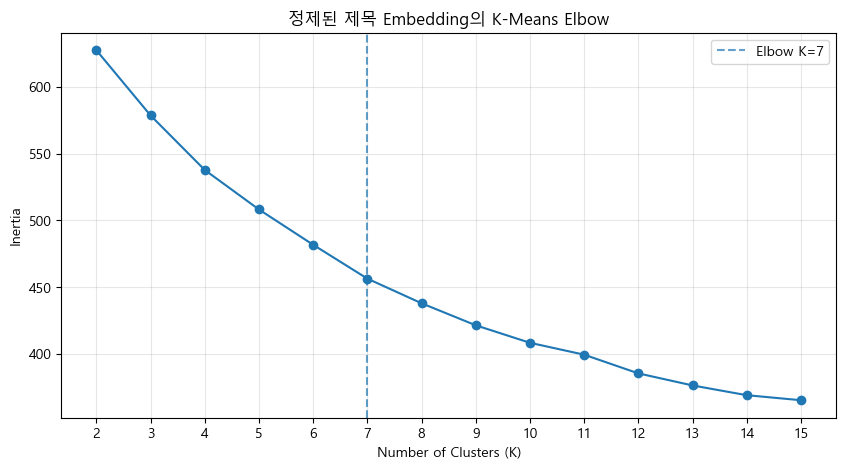

In [6]:
# 03. Elbow Method 시각화

plt.figure(figsize=(10, 5))

plt.plot(
    k_metrics["k"],
    k_metrics["inertia"],
    marker="o"
)

plt.axvline(
    elbow_k,
    linestyle="--",
    alpha=0.7,
    label=f"Elbow K={elbow_k}"
)

plt.title("정제된 제목 Embedding의 K-Means Elbow")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_metrics["k"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()


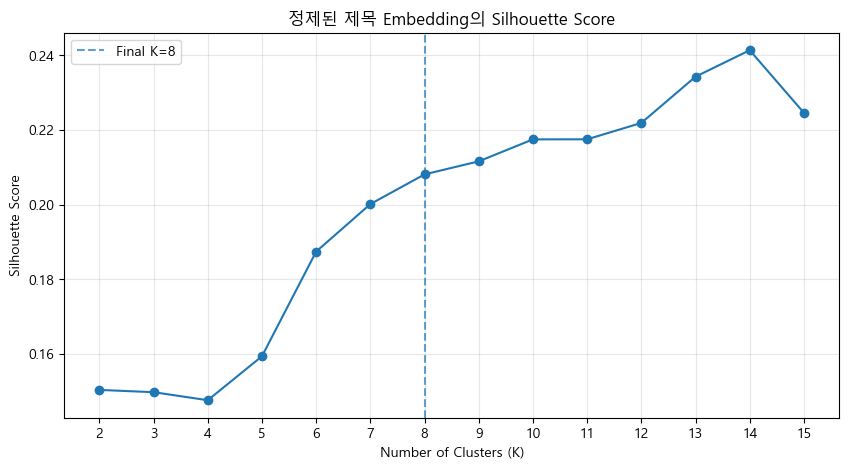

최종 K = 8
최종 K Silhouette = 0.2081
전역 최고 Silhouette K = 14


In [7]:
# 04. Silhouette Score 시각화 + 최종 K 확인

plt.figure(figsize=(10, 5))

plt.plot(
    k_metrics["k"],
    k_metrics["silhouette"],
    marker="o"
)

plt.axvline(
    FINAL_K,
    linestyle="--",
    alpha=0.7,
    label=f"Final K={FINAL_K}"
)

plt.title("정제된 제목 Embedding의 Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_metrics["k"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

selected_row = k_metrics[k_metrics["k"] == FINAL_K].iloc[0]

print(f"최종 K = {FINAL_K}")
print(f"최종 K Silhouette = {selected_row['silhouette']:.4f}")
print(f"전역 최고 Silhouette K = {silhouette_best_k}")


### K 선택 해석

이제 K 선택과 최종 군집화가 모두 **정제된 동일 Embedding**을 기준으로 이어진다.

따라서 이전처럼 `1차 K=5 → 텍스트 재정제 → 해석 목적 K=11`로 분석 공간과 선택 기준이 바뀌는 구간은 제거했다.

최종 K는 코드에서 계산된 `FINAL_K`를 그대로 사용한다. AI·SaaS·Cloud가 더 잘 보인다는 이유만으로 K를 추가로 늘리지 않는다.


## 5. 최종 K-Means 군집화

위 단계에서 선택된 `FINAL_K`를 그대로 적용한다. 군집 번호는 단순 식별자이며 의미 라벨은 다음 단계에서 TF-IDF와 대표 사례를 함께 보고 해석한다.


In [8]:
# 05. 최종 K-Means

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

df_analysis["cluster"] = kmeans.fit_predict(embeddings)

print("최종 Cluster 수:", FINAL_K)
print("Cluster별 건수:")
display(
    df_analysis["cluster"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


최종 Cluster 수: 8
Cluster별 건수:


,count
cluster,
0,66
1,179
2,187
3,145
4,79
5,112
6,150
7,194


## 6. 군집 해석: TF-IDF 핵심어 + 대표 사례

각 군집을 특정 기술명으로 미리 지정하지 않는다.

1. 군집 내부 정제 제목의 TF-IDF 상위 키워드를 확인하고,
2. K-Means 중심에 가까운 실제 승인 제목을 대표 사례로 함께 본다.

자동 라벨은 탐색 편의를 위한 요약이며 정책기관의 공식 분류명이 아니다.


In [9]:
# 06. Cluster별 핵심 키워드와 대표 사례

cluster_summary = []

for cluster_id in sorted(df_analysis["cluster"].unique()):
    mask = df_analysis["cluster"] == cluster_id
    temp = df_analysis.loc[mask].copy()
    temp_embeddings = embeddings[mask.to_numpy()]

    texts = temp["analysis_text"].replace("", np.nan).dropna()

    keywords = []

    if len(texts) > 0:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2 if len(texts) >= 5 else 1,
            max_features=5000
        )

        try:
            X = vectorizer.fit_transform(texts)
            terms = np.array(vectorizer.get_feature_names_out())
            scores = np.asarray(X.mean(axis=0)).ravel()
            top_idx = scores.argsort()[::-1][:10]
            keywords = terms[top_idx].tolist()
        except ValueError:
            keywords = []

    # 군집 중심에 가까운 실제 승인사례 3개
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(temp_embeddings - center, axis=1)
    representative_idx = np.argsort(distances)[:3]

    representative_titles = (
        temp.iloc[representative_idx]["title"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    cluster_summary.append({
        "cluster": cluster_id,
        "count": len(temp),
        "ratio": round(len(temp) / len(df_analysis) * 100, 1),
        "keywords": ", ".join(keywords),
        "auto_label": " / ".join(keywords[:3]) if keywords else f"Cluster {cluster_id}",
        "representative_titles": " | ".join(representative_titles)
    })


cluster_summary = pd.DataFrame(cluster_summary)
cluster_summary = cluster_summary.sort_values(
    ["count", "cluster"],
    ascending=[False, True]
).reset_index(drop=True)

display(cluster_summary)


,cluster,count,ratio,keywords,auto_label,representative_titles
0,7,194,17.4,"ai, 생성형, 생성형 ai, ai를, 생성형 ai를, azure, 위한, 플랫폼,...",ai / 생성형 / 생성형 ai,생성형 AI 기술 기반 대고객 시황 정보 제공 서비스 | 클라우드(SaaS) 기반 ...
1,2,187,16.8,"일반, 일반 공모펀드의, 상장클래스, 상장클래스 신설을, 상장거래, 공모펀드의 상장...",일반 / 일반 공모펀드의 / 상장클래스,마이데이터를 활용한 금리인하요구권 대행 서비스 | 마이데이터를 활용한 금리인하요구권...
2,1,179,16.1,"saas, 내부망, 클라우드를, saas 내부망, 소프트웨어 saas, 소프트웨어,...",saas / 내부망 / 클라우드를,클라우드를 활용한 협업툴 소프트웨어 서비스(SaaS)의 내부망 이용 | 클라우드를 ...
3,6,150,13.5,"플랫폼을, 온라인, 플랫폼, 온라인 플랫폼을, 모바일, 예금상품, 플랫폼을 예금상품...",플랫폼을 / 온라인 / 플랫폼,온라인 플랫폼을 통한 예금상품 비교·추천 서비스 | 온라인 플랫폼을 통한 예금상품 ...
4,3,145,13.0,"대한, 연계투자, 온라인투자연계금융업자, 대한 연계투자, 온라인투자연계금융업, 신용...",대한 / 연계투자 / 온라인투자연계금융업자,온라인투자연계금융업자 개인신용대출 차주에 대한 연계투자 | 온라인투자연계금융업자 개...
5,5,112,10.1,"m365, copilot, m365 copilot, 내부망, 클라우드를, 소프트웨어...",m365 / copilot / m365 copilot,클라우드(SaaS) 기반 임직원 협업 도구 (M365+Copilot)의 내부망 이용...
6,4,79,7.1,"금융기관보험대리점의 판매비중, 금융기관보험대리점의, 판매비중, 판매비중 규제, 규제...",금융기관보험대리점의 판매비중 / 금융기관보험대리점의 / 판매비중,금융기관보험대리점의 판매비중 규제 개선 | 금융기관보험대리점의 판매비중 규제 개선 ...
7,0,66,5.9,"소수단위, 소수단위 거래, 거래, 국내주식 소수단위, 국내주식, 해외주식, 해외주식...",소수단위 / 소수단위 거래 / 거래,해외주식 소수단위 거래 지원 서비스 | 해외주식 소수단위 거래 지원 서비스 | 해외...


## 7. 승인 시계열 분석

최종 군집별 승인 건수를 연도 단위로 집계한다.

AI·SaaS·Cloud 관련 군집은 **고정 Cluster 번호를 지정하지 않고**, 실제 제목에서 관련 키워드가 가장 많이 관찰되는 군집을 데이터 기반으로 연결한다. 서로 다른 기술 주제가 같은 군집에 매핑되면 이를 억지로 분리하지 않는다.


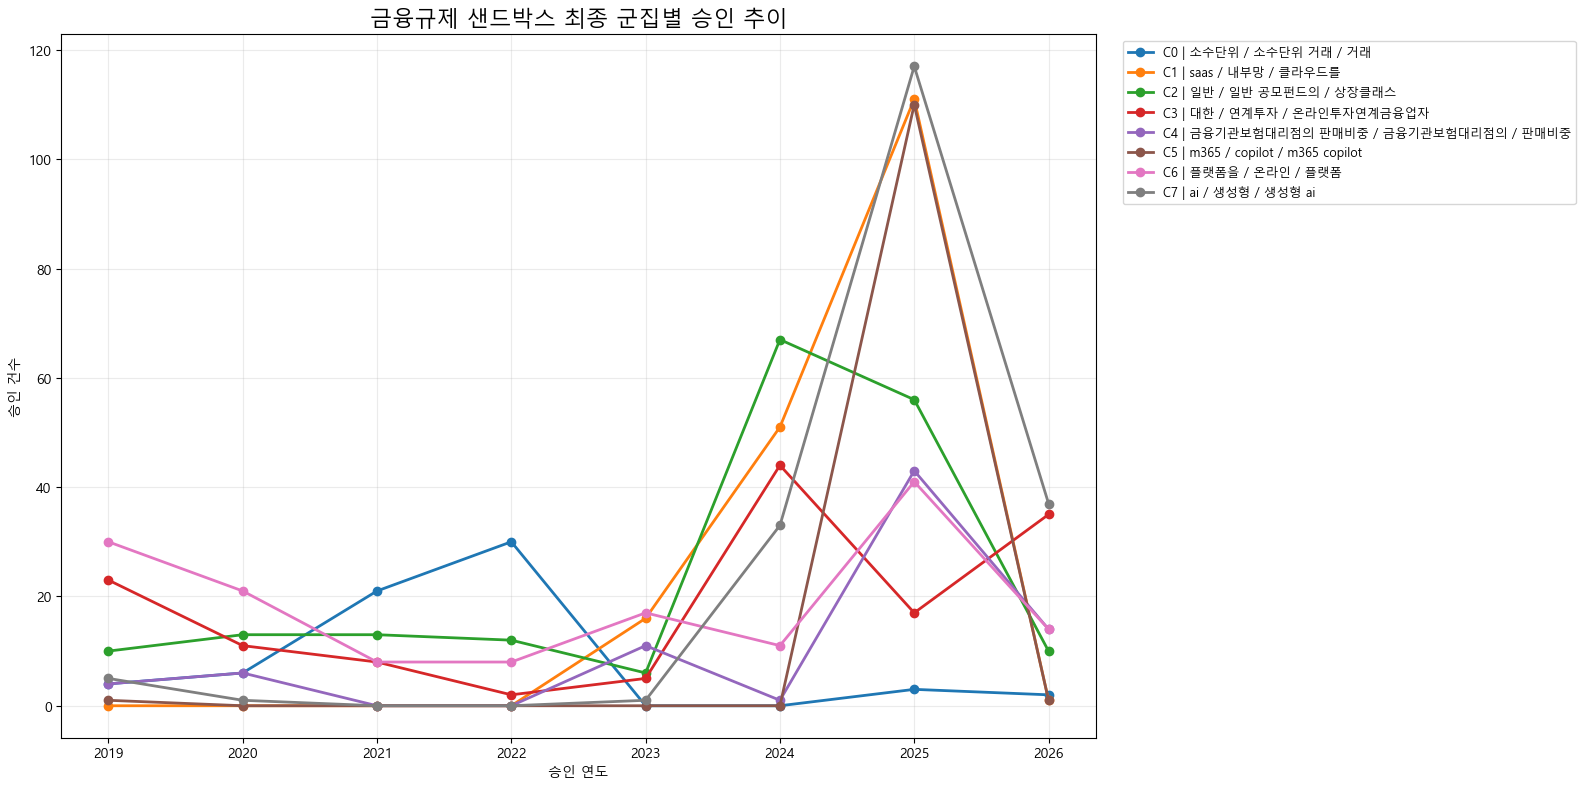

In [10]:
# 07. 전체 Cluster 승인일 기준 시계열

df_analysis["approval_date"] = pd.to_datetime(
    df_analysis["approval_date"],
    errors="coerce"
)

df_analysis["year"] = df_analysis["approval_date"].dt.year

year_cluster = (
    df_analysis
    .dropna(subset=["year"])
    .groupby(["year", "cluster"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

label_map = (
    cluster_summary
    .set_index("cluster")["auto_label"]
    .to_dict()
)

plt.figure(figsize=(16, 8))

for cluster_id in year_cluster.columns:
    plt.plot(
        year_cluster.index,
        year_cluster[cluster_id],
        marker="o",
        linewidth=2,
        label=f"C{cluster_id} | {label_map.get(cluster_id, '')}"
    )

plt.title("금융규제 샌드박스 최종 군집별 승인 추이", fontsize=16)
plt.xlabel("승인 연도")
plt.ylabel("승인 건수")
plt.xticks(year_cluster.index)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


,theme,cluster,theme_hits,cluster_count,within_cluster_ratio
0,AI·생성형 AI,7,180,194,0.928
1,SaaS·Cloud,1,174,179,0.972
2,M365·Copilot,5,84,112,0.750


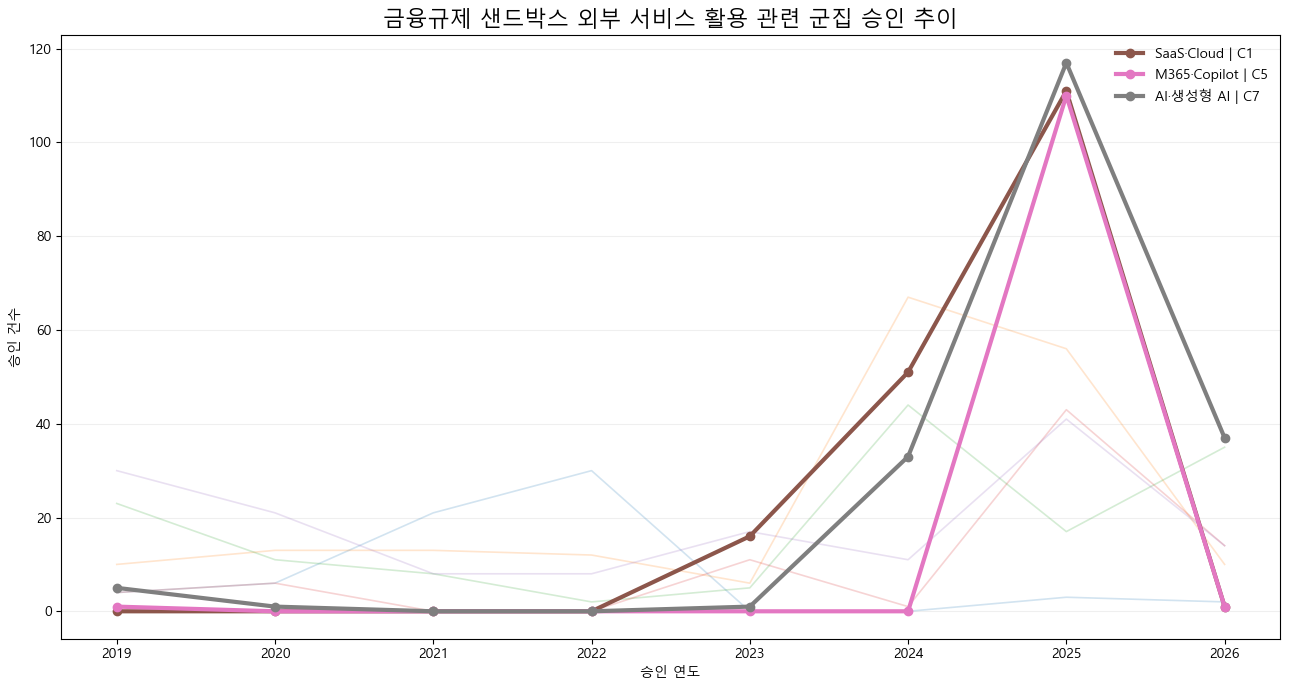

In [12]:
# 08. AI·SaaS·Cloud·M365 협업도구 관련 군집을 데이터 기반으로 탐색

TECH_THEMES = {
    "AI·생성형 AI": [
        "ai", "인공지능", "생성형", "llm", "챗봇"
    ],
    "SaaS·Cloud": [
        "saas", "cloud", "클라우드"
    ],
    "M365·Copilot": [
        "m365", "microsoft 365", "office 365", "copilot"
    ]
}


def keyword_hit(text, terms):
    text = "" if pd.isna(text) else str(text).lower()
    return any(term.lower() in text for term in terms)


theme_rows = []

for theme, terms in TECH_THEMES.items():
    theme_hit = df_analysis["title"].apply(
        lambda x: keyword_hit(x, terms)
    )

    temp = (
        df_analysis.loc[theme_hit]
        .groupby("cluster")
        .size()
        .rename("theme_hits")
        .reset_index()
    )

    if temp.empty:
        theme_rows.append({
            "theme": theme,
            "cluster": np.nan,
            "theme_hits": 0,
            "cluster_count": np.nan,
            "within_cluster_ratio": np.nan
        })
        continue

    cluster_counts = (
        df_analysis["cluster"]
        .value_counts()
        .rename("cluster_count")
    )

    temp["cluster_count"] = temp["cluster"].map(cluster_counts)

    temp["within_cluster_ratio"] = (
        temp["theme_hits"] / temp["cluster_count"]
    )

    best = temp.sort_values(
        ["theme_hits", "within_cluster_ratio"],
        ascending=[False, False]
    ).iloc[0]

    theme_rows.append({
        "theme": theme,
        "cluster": int(best["cluster"]),
        "theme_hits": int(best["theme_hits"]),
        "cluster_count": int(best["cluster_count"]),
        "within_cluster_ratio": round(
            float(best["within_cluster_ratio"]), 3
        )
    })


theme_cluster_map = pd.DataFrame(theme_rows)
display(theme_cluster_map)


valid_theme_map = (
    theme_cluster_map
    .dropna(subset=["cluster"])
    .copy()
)

valid_theme_map["cluster"] = (
    valid_theme_map["cluster"]
    .astype(int)
)

highlight_labels = (
    valid_theme_map
    .groupby("cluster")["theme"]
    .apply(lambda x: " + ".join(x))
    .to_dict()
)


plt.figure(figsize=(13, 7))

# 기타 군집
for cluster_id in year_cluster.columns:
    if cluster_id not in highlight_labels:
        plt.plot(
            year_cluster.index,
            year_cluster[cluster_id],
            linewidth=1.2,
            alpha=0.20
        )

# AI / SaaS·Cloud / M365·Copilot 강조
for cluster_id, theme_label in highlight_labels.items():

    if cluster_id in year_cluster.columns:

        plt.plot(
            year_cluster.index,
            year_cluster[cluster_id],
            marker="o",
            linewidth=3,
            label=f"{theme_label} | C{cluster_id}"
        )


plt.title(
    "금융규제 샌드박스 외부 서비스 활용 관련 군집 승인 추이",
    fontsize=16
)

plt.xlabel("승인 연도")
plt.ylabel("승인 건수")
plt.xticks(year_cluster.index)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

## 8. 분석 결론

금융규제 샌드박스 승인사례를 기준으로 기술 활용 흐름을 분석한 결과, AI·생성형 AI, SaaS·Cloud, M365·Copilot 기반 협업도구가 주요 기술군으로 확인되었다.

특히 최근에는 단순한 클라우드 활용을 넘어 업무 협업도구와 생성형 AI까지 외부 서비스 활용 범위가 확대되는 흐름이 나타난다.

SaaS·Cloud: 외부 클라우드 및 SaaS 기반 업무환경 확대
M365·Copilot: 외부 SaaS 기반 협업·업무도구 활용 확대
AI·생성형 AI: 외부 AI 서비스 활용 증가

따라서 금융권의 디지털 전환은 내부 시스템 중심에서 벗어나 Cloud → SaaS 업무도구 → 생성형 AI 등 외부 서비스와 연결되는 방향으로 확장되고 있음을 확인할 수 있다.

이러한 흐름은 이후 FPG에서 다루는 내부 금융환경과 외부 서비스 간 경계 확대의 산업적 배경으로 연결한다.